<a href="https://colab.research.google.com/github/DifferentiableUniverseInitiative/JaxPM/blob/main/notebooks/01-Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing JaxPM
# !pip install --quiet --upgrade jax
# !pip install --quiet jaxpm

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc

from jax.experimental.ode import odeint

from jaxpm.painting import cic_paint
from jaxpm.pm import linear_field, lpt, make_ode_fn

/home/dobos/project/covera/jax_cosmo/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [17]:
mesh_shape = [128, 128, 128]
box_size = [128. , 128., 128.]
snapshots = jnp.array([0.1, 0.5, 1.0, 1.05, 1.5, 2.5])
# snapshots = jnp.array([1.0, 5.0, 10.0])

@jax.jit
def run_simulation(omega_c, sigma8):
    # Create a small function to generate the matter power spectrum
    k = jnp.logspace(-4, 1, 128)
    pk = jc.power.linear_matter_power(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), k)
    # pk = jc.power.linear_matter_power(jc.EdS(Omega_c=omega_c, sigma8=sigma8), k)
    # pk = jc.power.linear_matter_power(jc.EdS9(Omega_c=omega_c, sigma8=sigma8), k)
    pk_fn = lambda x: jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)

    # Create initial conditions and particles
    initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(0))
    particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]),axis=-1).reshape([-1,3])

    # Initial displacement
    # cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)
    cosmo = jc.EdS(Omega_c=omega_c, sigma8=sigma8)
    # cosmo = jc.EdS9(Omega_c=omega_c, sigma8=sigma8)
    dx, p, f = lpt(cosmo, initial_conditions, particles, a=0.1)

    # Evolve the simulation forward
    res = odeint(make_ode_fn(mesh_shape), [particles + dx, p], snapshots, cosmo, rtol=1e-8, atol=1e-8)

    # Return the simulation volume at requested timesteps
    return initial_conditions ,  particles + dx , res[0]

In [18]:
# initial_conditions , lpt_particles , ode_particles = run_simulation(0.25, 0.8)
# initial_conditions , lpt_particles , ode_particles = run_simulation(1.0, 0.8)
initial_conditions , lpt_particles , ode_particles = run_simulation(0.3, 0.8)

/datascope/slurm/miniconda3/envs/dobos-jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


field: 0.10000000149011612 0.9482085704803467 1.0 0.1016605943441391 4.722478866577148
field: 0.10337589681148529 0.944880485534668 1.0 0.08313430845737457 4.976738929748535
field: 0.10023369640111923 0.9479589462280273 1.0 0.10035881400108337 4.739850044250488
field: 0.10035055130720139 0.9478565454483032 1.0 0.09970154613256454 4.748616695404053
field: 0.10093479603528976 0.9472647309303284 1.0 0.09643512219190598 4.792652606964111
field: 0.10103865712881088 0.9471688270568848 1.0 0.09585493803024292 4.800544738769531
field: 0.10116849094629288 0.9470298290252686 1.0 0.09512690454721451 4.810431480407715
field: 0.10116849094629288 0.9470310211181641 1.0 0.09512690454721451 4.81043004989624
field: 0.10157164931297302 0.9466468095779419 1.0 0.09287597239017487 4.8412394523620605
field: 0.1017732247710228 0.9464255571365356 1.0 0.09174324572086334 4.856873035430908
field: 0.10278110951185226 0.9454072117805481 1.0000001192092896 0.08610151708126068 4.935707092285156
field: 0.10296028852

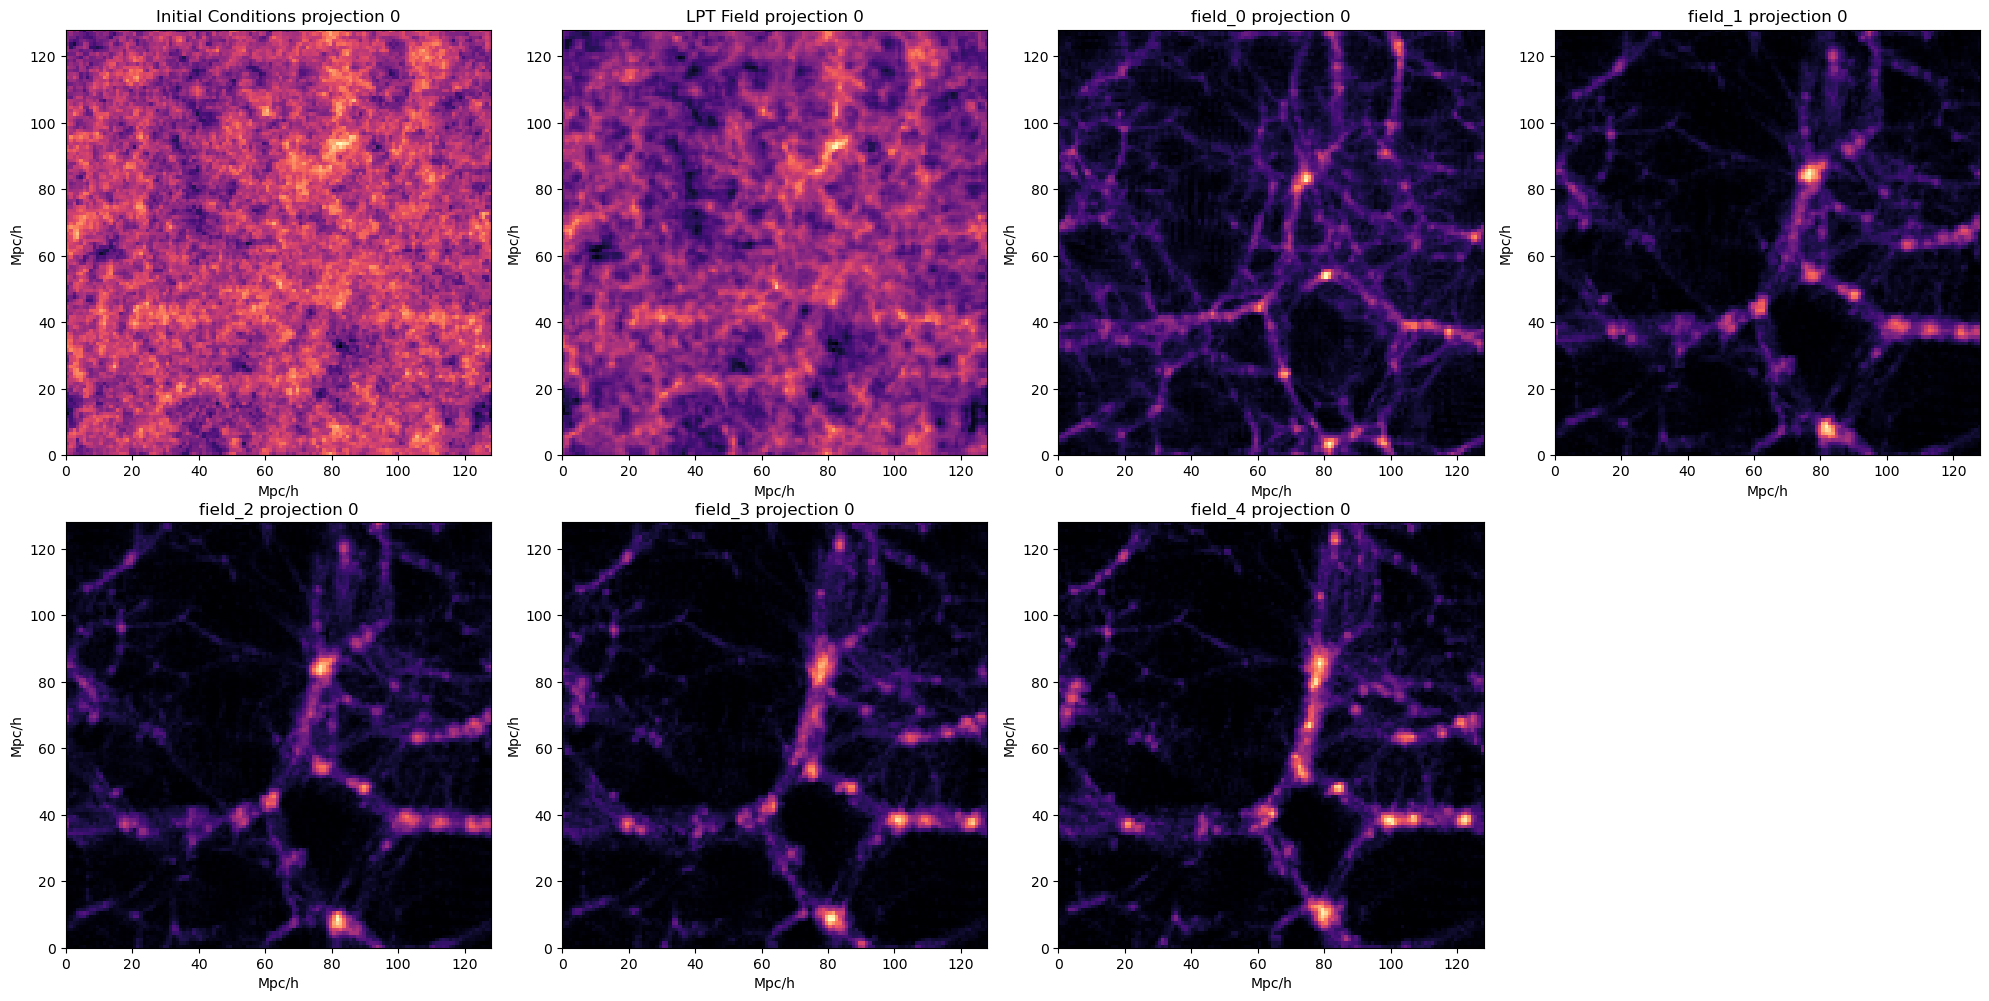

In [20]:
from jaxpm.plotting import plot_fields_single_projection

fields = {"Initial Conditions" : initial_conditions , "LPT Field" : jnp.log10(cic_paint(jnp.zeros(mesh_shape) ,lpt_particles) + 1)}
for i , field in enumerate(ode_particles[1:]):
    fields[f"field_{i}"] = jnp.log10(cic_paint(jnp.zeros(mesh_shape) , field)+1)
plot_fields_single_projection(fields)